# Notebook 01: Data Loading, EDA & Filtering Non-Emotional Reviews

**Deskripsi:** Notebook ini memuat ulasan Play Store mentah untuk aplikasi Twitter/X dari berkas `data/raw/reviews_playstore_indonesia.csv`, melakukan Exploratory Data Analysis (EDA) dasar, dan menyaring ulasan non-emosional/teknis untuk meminimalkan *noise* sebelum proses anotasi data 5 kelas emosi (*Joy, Anger, Sadness, Fear, Disgust*).

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Tambahkan path parent directory agar modul 'src' bisa diimpor
sys.path.append(os.path.abspath('../'))
from src.data_utils import load_and_filter_data, clean_raw_text

# Buat direktori data/processed jika belum ada
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)
print("Modul berhasil dimuat dan folder tujuan siap!")


Modul berhasil dimuat dan folder tujuan siap!


## 1. Memuat Data Mentah dan Analisis Awal

In [2]:
raw_csv_path = '../data/raw/reviews_playstore_indonesia.csv'
df_raw = pd.read_csv(raw_csv_path)

print("--- Dimensi Data Mentah ---")
print(df_raw.shape)
print("\n--- Informasi Kolom ---")
df_raw.info()

--- Dimensi Data Mentah ---
(49070, 11)

--- Informasi Kolom ---
<class 'pandas.DataFrame'>
RangeIndex: 49070 entries, 0 to 49069
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              49070 non-null  str    
 1   userName              49070 non-null  str    
 2   userImage             49070 non-null  str    
 3   content               49070 non-null  str    
 4   score                 49070 non-null  int64  
 5   thumbsUpCount         49070 non-null  int64  
 6   reviewCreatedVersion  36999 non-null  str    
 7   at                    49070 non-null  str    
 8   replyContent          0 non-null      float64
 9   repliedAt             0 non-null      float64
 10  appVersion            36999 non-null  str    
dtypes: float64(2), int64(2), str(7)
memory usage: 16.9 MB


## 2. Visualisasi Sebaran Score (Rating) Ulasan Mentah

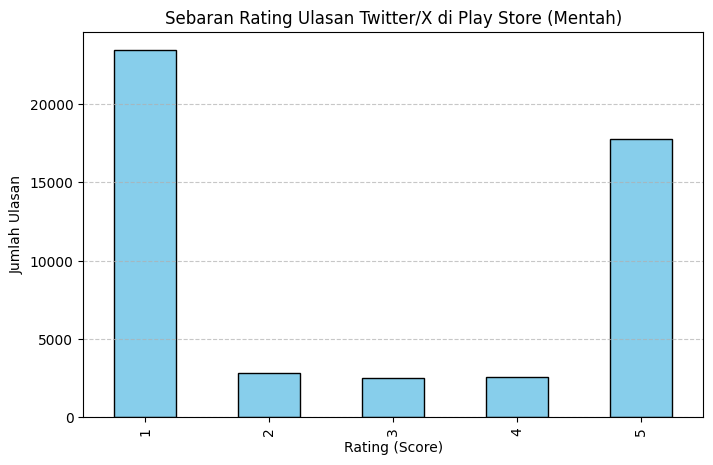

Detail Sebaran Rating:
score
1    23468
2     2790
3     2495
4     2565
5    17752
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(8, 5))
score_counts = df_raw['score'].value_counts().sort_index()
score_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Sebaran Rating Ulasan Twitter/X di Play Store (Mentah)')
plt.xlabel('Rating (Score)')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('../reports/figures/raw_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Detail Sebaran Rating:")
print(score_counts)


## 3. Proses Pemfilteran Ulasan Non-Emosional

Kami memanggil fungsi `load_and_filter_data` untuk menyaring ulasan yang mengandung emosi berdasarkan skor ekstrim (1 & 5) dan leksikon kata kunci afektif bahasa Indonesia.

In [4]:
df_filtered = load_and_filter_data(raw_csv_path)

Total ulasan mentah dimuat: 49070


Ulasan berhasil disaring (memiliki sinyal emosi): 44217
Ulasan non-emosional (dibuang): 4853


## 4. Analisis Panjang Teks Sebelum dan Sesudah Pemfilteran

Statistik Deskriptif Panjang Karakter (Data Mentah):
count    49070.000000
mean        55.951335
std         68.500897
min          1.000000
25%         12.000000
50%         31.000000
75%         73.000000
max        500.000000
Name: char_length, dtype: float64

Statistik Deskriptif Panjang Karakter (Data Tersaring):
count    44217.000000
mean        55.774612
std         69.073139
min          1.000000
25%         12.000000
50%         31.000000
75%         73.000000
max        500.000000
Name: char_length, dtype: float64


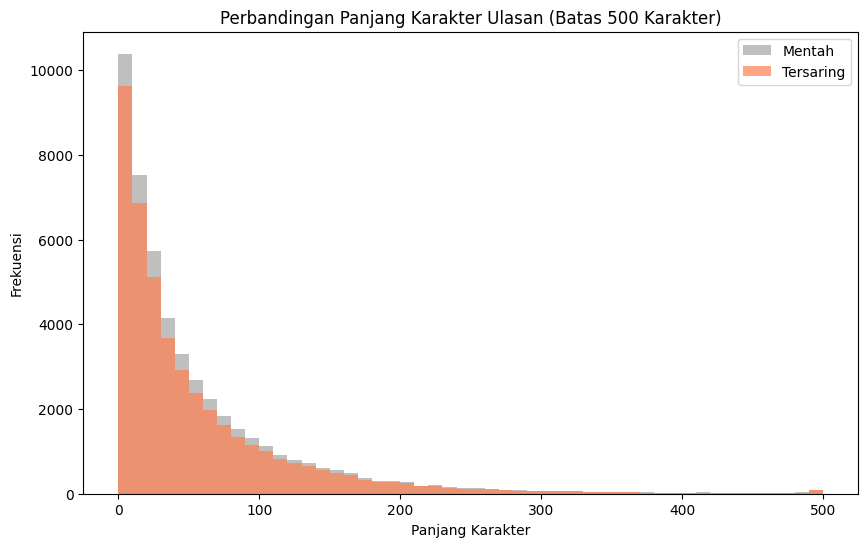

In [5]:
df_raw['char_length'] = df_raw['content'].apply(lambda x: len(str(x)))
df_filtered['char_length'] = df_filtered['content'].apply(lambda x: len(str(x)))

print("Statistik Deskriptif Panjang Karakter (Data Mentah):")
print(df_raw['char_length'].describe())

print("\nStatistik Deskriptif Panjang Karakter (Data Tersaring):")
print(df_filtered['char_length'].describe())

# Visualisasi Perbandingan
plt.figure(figsize=(10, 6))
plt.hist(df_raw['char_length'], bins=50, alpha=0.5, label='Mentah', color='grey', range=(0, 500))
plt.hist(df_filtered['char_length'], bins=50, alpha=0.7, label='Tersaring', color='coral', range=(0, 500))
plt.title('Perbandingan Panjang Karakter Ulasan (Batas 500 Karakter)')
plt.xlabel('Panjang Karakter')
plt.ylabel('Frekuensi')
plt.legend()
plt.savefig('../reports/figures/char_length_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Menyimpan Data Hasil Saringan

Data yang tersaring akan disimpan ke `data/processed/filtered_reviews.csv` untuk masuk ke tahap anotasi dan pra-pengolahan lanjutan.

In [6]:
output_csv_path = '../data/processed/filtered_reviews.csv'
df_filtered.to_csv(output_csv_path, index=False)
print(f"Dataset berhasil disimpan ke: {output_csv_path}")
print(f"Ukuran file hasil saringan: {df_filtered.shape}")

Dataset berhasil disimpan ke: ../data/processed/filtered_reviews.csv
Ukuran file hasil saringan: (44217, 13)
